In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


In [2]:
curv_dir ='/home/u0890475/Documents/SW_analysis_result/amr4/curvature'
strainrate_dir = '/home/u0890475/Documents/SW_analysis_result/amr4/strainrate'

In [5]:
curv_files=sorted([os.path.join(curv_dir,f) for f in os.listdir(curv_dir) if f.endswith('.csv')],)
strainrate_files=sorted([os.path.join(strainrate_dir,f) for f in os.listdir(strainrate_dir) if f.endswith('.csv')],)


In [7]:
def curvature_process(d1,yh2_u):
    df1 = pd.read_csv(d1)
    # calculate progress variable
    df1['c'] = 1 - df1['Y(H2)']/yh2_u
    df_ff = df1[(df1['c'] >=0.495)&(df1['c'] <=0.505)]
    df_ff_min=df_ff.loc[df_ff.groupby('y_grid')['x_grid'].idxmin()].copy()
    frontmost =df_ff_min['x_grid'].min()
    return df_ff_min,frontmost


def strainrate(d1):
    df1 = pd.read_csv(d1)

    sr_mean = df1['div_u'].mean()
    sr_median = df1['div_u'].replace([np.inf, -np.inf], np.nan).median()
    return sr_mean, sr_median

In [91]:
strainrate_files[0]

'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate/plt70800_strain_rate.csv'

In [95]:
curv_files[0]

'/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt70800_curvature.csv'

In [11]:
all_ff_min=[]
frontmost_list=[]
sr_mean_list=[]
for i in range(len(curv_files)):
    df_ff_min,frontmost=curvature_process(
        curv_files[i],
        yh2_u=0.012181,
    )
    timestep= curv_files[i].split('/')[-1]
    frontmost_list.append({
        'file':timestep,
        'frontmost':frontmost,
    })

df_frontmost=pd.DataFrame(frontmost_list)

In [13]:
for i in range(len(strainrate_files)):
    timestep= strainrate_files[i].split('/')[-1]
    sr_mean,sr_median=strainrate(strainrate_files[i])
    sr_mean_list.append({
        'file':timestep,
        'sr_mean':sr_mean,
        'sr_median':sr_median,
    })
    print(f'Time step {timestep} is finished.')

df_sr_mean=pd.DataFrame(sr_mean_list)

Time step plt70800_strain_rate.csv is finished.
Time step plt71000_strain_rate.csv is finished.
Time step plt71200_strain_rate.csv is finished.
Time step plt71400_strain_rate.csv is finished.
Time step plt71600_strain_rate.csv is finished.
Time step plt71800_strain_rate.csv is finished.
Time step plt72000_strain_rate.csv is finished.
Time step plt72200_strain_rate.csv is finished.
Time step plt72400_strain_rate.csv is finished.
Time step plt72600_strain_rate.csv is finished.
Time step plt72800_strain_rate.csv is finished.
Time step plt73000_strain_rate.csv is finished.
Time step plt73200_strain_rate.csv is finished.
Time step plt73400_strain_rate.csv is finished.
Time step plt73600_strain_rate.csv is finished.
Time step plt73800_strain_rate.csv is finished.
Time step plt74000_strain_rate.csv is finished.
Time step plt74200_strain_rate.csv is finished.
Time step plt74400_strain_rate.csv is finished.
Time step plt74600_strain_rate.csv is finished.
Time step plt74800_strain_rate.csv is fi

In [15]:
df_frontmost['movement']='stationary'
for i in range(len(df_frontmost)-1):
    x1=df_frontmost.loc[i,'frontmost']
    x2=df_frontmost.loc[i+1,'frontmost']
    if x2>x1:
        movement='backward'
    elif x2<x1:
        movement='forward'
    else:
        movement='stationary'
    df_frontmost.loc[i+1,'movement']=movement



In [21]:
df_plot=df_sr_mean.copy()
df_plot['movement']=df_frontmost['movement']

# remove first point
df_plot=df_plot.iloc[2:].copy()

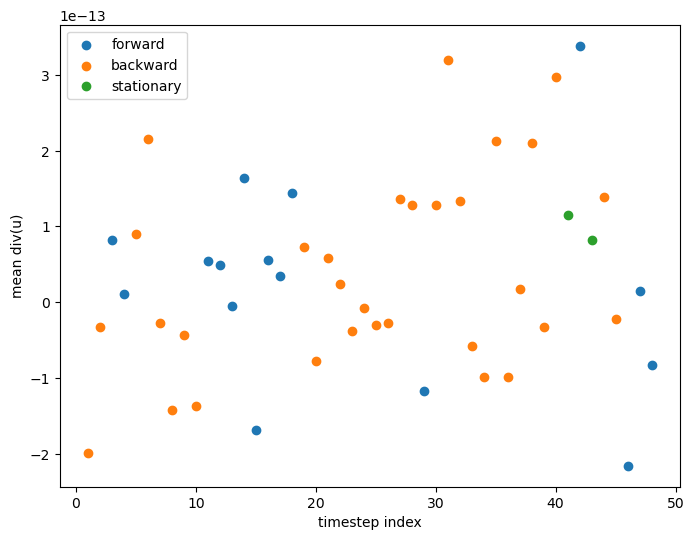

In [19]:
import matplotlib.pyplot as plt

forward=df_plot[df_plot['movement']=='forward']
backward=df_plot[df_plot['movement']=='backward']
stationary=df_plot[df_plot['movement']=='stationary']

plt.figure(figsize=(8,6))

plt.scatter(
    forward.index,
    forward['sr_mean'],
    label='forward',
)

plt.scatter(
    backward.index,
    backward['sr_mean'],
    label='backward',
)

plt.scatter(
    stationary.index,
    stationary['sr_mean'],
    label='stationary',
)

plt.ylabel('mean div(u)')
plt.xlabel('timestep index')
plt.savefig('./result/flamefront vs strainrate.png',dpi=600)

plt.legend()

plt.show()

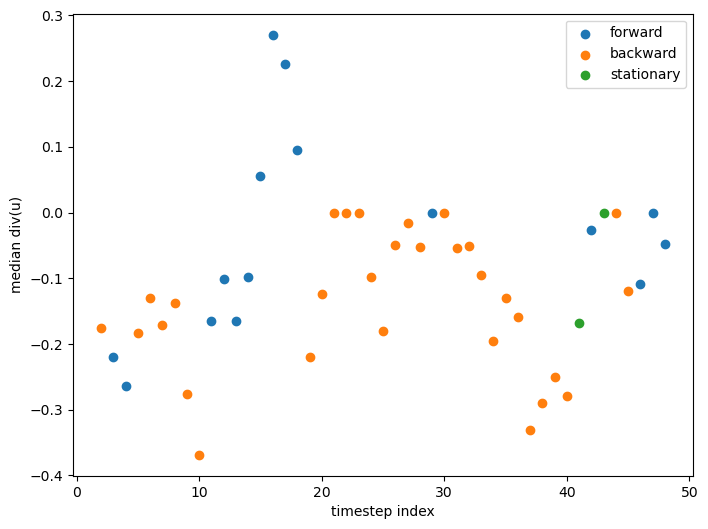

In [29]:
import matplotlib.pyplot as plt

forward=df_plot[df_plot['movement']=='forward']
backward=df_plot[df_plot['movement']=='backward']
stationary=df_plot[df_plot['movement']=='stationary']

plt.figure(figsize=(8,6))

plt.scatter(
    forward.index,
    forward['sr_median'],
    label='forward',
)

plt.scatter(
    backward.index,
    backward['sr_median'],
    label='backward',
)

plt.scatter(
    stationary.index,
    stationary['sr_median'],
    label='stationary',
)

plt.ylabel('median div(u)')
plt.xlabel('timestep index')
plt.savefig('./result/flamefront vs strainrate(median).png',dpi=600)

plt.legend()

plt.show()

In [27]:
df_sr_mean

,file,sr_mean,sr_median
0,plt70800_strain_rate.csv,-6.002653e-14,-0.093333
1,plt71000_strain_rate.csv,-1.991790e-13,-0.261159
2,plt71200_strain_rate.csv,-3.274175e-14,-0.174915
3,plt71400_strain_rate.csv,8.185436e-14,-0.219603
4,plt71600_strain_rate.csv,1.091392e-14,-0.263517
5,plt71800_strain_rate.csv,9.003980e-14,-0.183784
6,plt72000_strain_rate.csv,2.155498e-13,-0.130631
7,plt72200_strain_rate.csv,-2.728479e-14,-0.170378
8,plt72400_strain_rate.csv,-1.418809e-13,-0.138092
9,plt72600_strain_rate.csv,-4.365566e-14,-0.276132


In [69]:
def curvature_plot(d1,yh2_u):
    df1 = pd.read_csv(d1)
    # calculate progress variable
    df1['c'] = 1 - df1['Y(H2)']/yh2_u
    df_ff = df1[(df1['c'] >=0.495)&(df1['c'] <=0.505)].reset_index(drop=True)
    #df_ff_min=df_ff.loc[df_ff.groupby('y_grid')['x_grid'].idxmin()].copy()
    idx_min = df_ff['x_grid'].idxmin()
    ffx,ffy,ffz =df_ff['x_grid'].iloc[idx_min],df_ff['y_grid'].iloc[idx_min],df_ff['z_grid'].iloc[idx_min],
    df_ffz = df_ff[df_ff['z_grid'] ==ffz]
    plt.plot(df_ff['x_grid'],df_ff['y_grid'],marker='.',markersize=1,)
    
    plt.show()
    return ffx,ffy,ffz

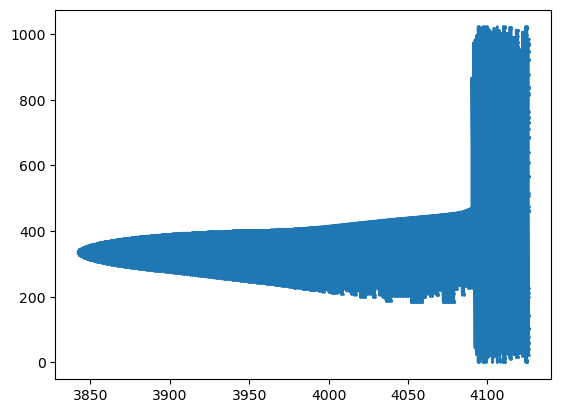

(3842, 332, 0)

In [71]:
curvature_plot('/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt70800_curvature.csv',yh2_u=0.012181,)

In [179]:
df1= pd.read_csv('/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt73400_curvature.csv')

In [183]:
df1['c'] =  1- df1['Y(H2)']/0.012181
df1_f= df1[df1['c']>=0.495]
df_ffm =df1_f.loc[df1_f.groupby('y_grid')['x_grid'].idxmin()].copy()


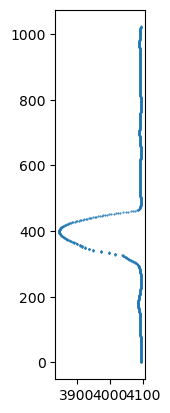

In [193]:
plt.plot(df_ffm['x_grid'],df_ffm['y_grid'],'.',markersize=1)
plt.gca().set_aspect('equal')
plt.show()

In [73]:
def plot_strainrate_slice(
    d1,
    d2,
    yh2_u,
    method=1,
    file_label='',
    esr=10000,
):
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,9))
    # d1: strain rate
    # d2: curvature
    df = pd.read_csv(d1)
    name = d1.split('/')[-1].split('.')[0]
    
    dfcurv = pd.read_csv(d2)
    dfcurv['c'] = 1 - dfcurv['Y(H2)']/yh2_u
    df_ff = dfcurv[(dfcurv['c'] >=0.495)].reset_index(drop=True)
    #df_fi = dfcurv[(dfcurv['c'] >=0.1)].reset_index(drop=True)
    #df_f05 = dfcurv[(dfcurv['c'] >=0.01)].reset_index(drop=True)
    #idx_min = df_ff['x_grid'].idxmin()
    ffz =df_ff['z_grid'].iloc[idx_min]
    #ffzi =df_fi['z_grid'].iloc[idx_min]
    df_ffz = df_ff[df_ff['z_grid'] ==ffz]
    #df_ffzi = df_fi[df_fi['z_grid'] ==ffz]
    #df_ffz05 = df_f05[df_f05['z_grid'] ==ffz]
    df_ffm = df_ffz.loc[df_ffz.groupby('y_grid')['x_grid'].idxmin()].copy()
    #df_ffi = df_ffzi.loc[df_ffzi.groupby('y_grid')['x_grid'].idxmin()].copy()
    #df_ff05 = df_ffz05.loc[df_ffz05.groupby('y_grid')['x_grid'].idxmin()].copy()
    # thats where the flame is located at chosen c=0.5 as the flame location
    #plt.plot(df_ff05['x_grid'],df_ff05['y_grid'],'-.',markersize=2,color='lightgray',label='c=0.01')
    #plt.plot(df_ffi['x_grid'],df_ffi['y_grid'],'.',markersize=2,color='dimgrey',label='c=0.1')
    plt.plot(df_ffm['x_grid'],df_ffm['y_grid'],'.',markersize=2,color='black',label='c=0.5')
    
    df2=df[df['z_grid']==ffz].copy()
    for i in range(8):
        df_zcut = df_ff[df_ff['z_grid']==i]
        df_z01 = df_zcut[df_zcut['c']>=0.05]
        df_z05 = df_zcut[df_zcut['c']>=0.5]
        df_ff01 = df_z01.loc[df_z01.groupby('y_grid')['x_grid'].idxmin()].copy()
        df_ff05 = df_z05.loc[df_z05.groupby('y_grid')['x_grid'].idxmin()].copy()

        plt.plot(df_ff01['x_grid'],df_ff01['y_grid'],'.',markersize=2,color='lightgray',label='c=0.05')
        plt.plot(df_ff05['x_grid'],df_ff05['y_grid'],'.',markersize=2,color='lightgray',label='c=0.5')
        df2=df[df['z_grid']==i].copy()
    # method 1, directly plot strain rate with normal scale
    if(method==1):
        divu_grid=df2.pivot_table(
            index='y_grid',
            columns='x_grid',
            values='div_u',
            aggfunc='median',
        )
        levels=np.linspace(
            -2000,
            2000,
            100,
        )
        vmin=-2000
        vmax=2000
        X=divu_grid.columns.values
        Y=divu_grid.index.values
        Z=divu_grid.values
        cf=plt.contourf(
            X,
            Y,
            Z,
            levels=levels,
            cmap='seismic',
            vmin=vmin,
            vmax=vmax,
        )
             
        X=divu_grid.columns.values
        Y=divu_grid.index.values
        Z=divu_grid.values
        plt.gca().set_aspect('equal')
        plt.colorbar(cf,label = 'Strain Rate')
        plt.xlabel('x_grid')
        plt.ylabel('y_grid')
        plt.title(f'z_grid={ffz}')


    # method 2
    elif(method==2):
        df2['log_abs_div_u'] =np.log10(abs(df2['div_u']+1e-5))
        divu_grid=df2.pivot_table(
            index='y_grid',
            columns='x_grid',
            values='log_abs_div_u',
            aggfunc='median',
        )
        levels=np.linspace(
            0,
            10,
            51,
        )
        vmin=-10
        vmax=10
        X=divu_grid.columns.values
        Y=divu_grid.index.values
        Z=divu_grid.values
        cf=plt.contourf(
            X,
            Y,
            Z,
            levels=levels,
            cmap='YlGn',
            vmin=vmin,
            vmax=vmax,
        )
             
        X=divu_grid.columns.values
        Y=divu_grid.index.values
        Z=divu_grid.values
        plt.gca().set_aspect('equal')
        plt.colorbar(cf,label='Absolute Strain Rate in Log10-scale')
        plt.xlabel('x_grid')
        plt.ylabel('y_grid')
        plt.title(f'z_grid={ffz}')

    # for this section, highlight the region that has higher value than the extinction strain rate from cantera
    """

    """

    plt.ylim(0,1024)
    plt.xlim(3510,4050)
    plt.tight_layout()
    plt.legend()
    #plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_strainrate.png',dpi=600)
    plt.show()

In [421]:
# The section above is copied as the function backup
# get dudx
cf_x=plt.contourf(X,Y,dudx_grid.values,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
cbar =plt.colorbar(cf_x,label='Strain Rate in power of 10-scale')
cbar.formatter=FuncFormatter(log_label)
cbar.update_ticks()
plt.xlabel('x_grid')
plt.ylabel('y_grid')
plt.title(f'z_grid={i} w/ max abs dudx :{round(max(dudx_grid.values),2)} 1/s.')
plt.ylim(0,1024)
plt.xlim(3510,4050)
plt.tight_layout()
plt.legend()
plt.show()


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
def log_label(x,pos):
        if np.isclose(x,0):
            return "0"
        sign= "-" if x<0 else ""
        exp=int(np.round(abs(x)))
        return rf"${sign}10^{{{abs(int(x))}}}$"



def plot_flame_contour(df_ff01,df_ff05,label1='c=0.1',label2='c=0.5'):
    fig,ax = plt.subplots(figsize=(12,9))
    ax.plot(df_ff01['x_grid'],df_ff01['y_grid'],'.',markersize=2,color='dimgrey',label=label1)
    ax.plot(df_ff05['x_grid'],df_ff05['y_grid'],'.',markersize=2,color='black',label=label2)
    
    return fig,ax

def plot_sr_sum_v11(df_ff01,df_ff05,df,sr_threshold,i,name,file_label=''):
    df2 = df.copy()


    #df2 = df[df['Sd'].notna()].copy()
    try:
        df2['stretch_rate'] = df2['div_u'] + df2['k']*df2['Sd']
    except:
        print("Unable to get Stretch rate!!!")

    df2_flame = df2[ (df2['c']>=0.15) & (df2['c']<=0.85) & (df2['Sd'] == df2['Sd'] ) ]
    max_str = df2_flame['stretch_rate'].max()
    # plot flame range
    fig,ax=plot_flame_contour(df_ff01,df_ff05,label1='c=0.15',label2='c=0.85')
    pn_divu = np.where(df2['div_u']>0,1,-1)
    log_abs_divu = np.log10(abs(df2['div_u'])+1e-5)
    df2['pn_log_divu'] = pn_divu  * log_abs_divu
    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_divu',
        aggfunc='median',
    )
    pn_str = np.where(df2['stretch_rate']>0,1,-1)
    log_abs_str = np.log10(abs(df2['stretch_rate'])+1e-5)
    df2_flame['np_log_str'] = pn_str*log_abs_str
    str_grid = df2_flame.pivot_table(index='y_grid', columns='x_grid', values='np_log_str', aggfunc='median',)
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    
    X1=str_grid.columns.values
    Y1=str_grid.index.values
    Z1=str_grid.values
    
    max_sr = np.abs(df2[df2['c']<=0.5]['div_u']).max()
    
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
    cf1 = ax.contourf(X1,Y1,Z1,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    cf2= ax.contourf(X1,Y1,np.abs(Z1)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
    cbar =plt.colorbar(cf,ax=ax,label='Strain Rate in power of 10-scale')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabel('y_grid')
    ax.set_title(f'z_grid={i} w/ max stretch rate:{round(max_str,2)} 1/s,\n max abs strain rate :{round(max_sr,2)} 1/s.')
    ax.legend()
    fig.tight_layout()
    plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_(sr)(str)sum_z={i}.png',dpi=600)
    print(f'plot saved for layer i={i}!')
    plt.show()

def plot_sr_sum(
    df_fflow,
    df_ffhigh,
    df,
    sr_threshold,
    i,
    name,
    file_label='',
):

    df2=df.copy()    
    
    df2_flame=df2[
        (df2['c']>=0.2)
        &
        (df2['c']<=0.8)
        &
        (df2['Sd'].notna())
    ].copy()
    try:
        df2_flame = df2.copy()
        df2_flame['stretch_rate']=(
            df2_flame['div_u']
            +
            df2_flame['k']*df2_flame['Sd']
        )
        max_str=df2_flame['stretch_rate'].max()
    except:
        print("Unable to get Stretch rate at begining!!!")
    
    
    df2_flame['sdk']=(
        df2_flame['Sd']
        *
        df2_flame['k']
    )
    #print(df2.columns)
    #print(df2_flame.columns)

    

    fig,axs=plt.subplots(
        2,
        2,
        figsize=(18,18)
    )

    ax=axs[0,0]
    ax_sd=axs[1,1]
    ax_k=axs[1,0]
    ax_sdk=axs[0,1]

    # ============================================================
    # flame contours on all panels
    # ============================================================
    #df_ff015 = df2[df2['c']>=0.15]
    #df_ff085 = df2[df2['c']>=0.85]
    #df_fflow = df2_flame.loc[df2_flame.groupby('y_grid')['x_grid'].idxmin()].copy()
    #df_ffhigh = df2_flame.loc[df2_flame.groupby('y_grid')['x_grid'].idxmax()].copy()
    for a in [ax,ax_sd,ax_k,ax_sdk]:

        a.plot(
            df_fflow['x_grid'],
            df_fflow['y_grid'],
            '.',
            markersize=2,
            color='dimgrey',
            label='c=0.2'
        )

        a.plot(
            df_ffhigh['x_grid'],
            df_ffhigh['y_grid'],
            '.',
            markersize=2,
            color='black',
            label='c=0.8'
        )
        a.legend(loc=2)

    # ============================================================
    # original strain/stretch panel
    # ============================================================

    pn_divu=np.where(
        df2['div_u']>0,
        1,
        -1
    )

    log_abs_divu=np.log10(
        np.abs(df2['div_u'])+1e-5
    )

    df2['pn_log_divu']=(
        pn_divu
        *
        log_abs_divu
    )

    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_divu',
        aggfunc='median',
    )

    pn_str=np.where(
        df2_flame['stretch_rate']>0,
        1,
        -1
    )

    log_abs_str=np.log10(
        np.abs(df2_flame['stretch_rate'])+1e-5
    )

    df2_flame['pn_log_str']=(
        pn_str
        *
        log_abs_str
    )

    str_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_str',
        aggfunc='median',
    )

    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values

    X1=str_grid.columns.values
    Y1=str_grid.index.values
    Z1=str_grid.values

    levels=np.linspace(
        -4,
        4,
        33
    )

    cf=ax.contourf(
        X,
        Y,
        Z,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
        alpha=0.7
    )

    cf1=ax.contourf(
        X1,
        Y1,
        Z1,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cf2=ax.contourf(
        X1,
        Y1,
        np.abs(Z1)>=np.log10(sr_threshold),
        levels=[0.5,1],
        hatches=['xx'],
        alpha=0.5,
    )

    cbar=plt.colorbar(
        cf,
        ax=ax
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    max_sr=np.abs(
        df2[df2['c']<=0.5]['div_u']
    ).max()

    ax.set_title(
        f'Strain / Stretch\n'
        f'max stretch={round(max_str,2)} 1/s\n'
        f'max abs strain={round(max_sr,2)} 1/s'
    )

    # ============================================================
    # Sd panel (NO LOG)
    # ============================================================

    sd_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='Sd',
        aggfunc='median',
    )

    cf_sd=ax_sd.contourf(
        sd_grid.columns.values,
        sd_grid.index.values,
        sd_grid.values,
        levels=np.linspace(-3,3,25),
        cmap='bwr',
        vmin=-3,
        vmax=3,
        extend='both',
    )

    plt.colorbar(
        cf_sd,
        ax=ax_sd,
        label='Sd [m/s]'
    )

    ax_sd.set_title('Sd')

    # ============================================================
    # Curvature panel
    # ============================================================

    
    c02_df = (df[df['c'] >= 0.2]
        .groupby(['z_grid','y_grid'])['x_grid']
        .min()
        .rename('x_c02')
        .reset_index()
    )
    
    # 找每个 z,y 上 c>=0.8 的最左 x，也就是 c=0.8 前沿
    c08_df = (
        df[df['c'] >= 0.8]
        .groupby(['z_grid','y_grid'])['x_grid']
        .min()
        .rename('x_c08')
        .reset_index()
    )
    
    df2 = df.merge(
        c02_df,
        on=['z_grid','y_grid'],
        how='inner'
    )
    
    df2 = df2.merge(
        c08_df,
        on=['z_grid','y_grid'],
        how='inner'
    )

    x_left = np.minimum(df2['x_c02'], df2['x_c08'])
    x_right = np.maximum(df2['x_c02'], df2['x_c08'])
    
    df2 = df2[
        (df2['x_grid'] >= x_left)
        &
        (df2['x_grid'] <= x_right)
    ].copy()
    
    df2.drop(
        columns=['x_c02','x_c08'],
        inplace=True
    )

    try:
        df2_flame = df2.copy()
        df2_flame['stretch_rate']=(
            df2_flame['div_u']
            +
            df2_flame['k']*df2_flame['Sd']
        )
        max_str=np.abs(df2_flame['stretch_rate']).max()
    except:
        print("Unable to get Stretch rate!!!")
    df2_flame['sdk']=(
        df2_flame['Sd']
        *
        df2_flame['k']
    )
    

    df2_flame['plot_k']=(
        np.sign(df2_flame['k'])* np.log10(np.abs(df2_flame['k'])+1e-5)
    )

    k_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='plot_k',
        aggfunc='median',
    )

    cf_k=ax_k.contourf(
        k_grid.columns.values,
        k_grid.index.values,
        k_grid.values,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cbar=plt.colorbar(
        cf_k,
        ax=ax_k,
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    ax_k.set_title('Curvature')

    # ============================================================
    # Sd*k panel
    # ============================================================

    df2_flame['plot_sdk']=(
        np.sign(df2_flame['sdk'])
        *
        np.log10(
            np.abs(df2_flame['sdk'])+1e-5
        )
    )

    sdk_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='plot_sdk',
        aggfunc='median',
    )

    cf_sdk=ax_sdk.contourf(
        sdk_grid.columns.values,
        sdk_grid.index.values,
        sdk_grid.values,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cbar=plt.colorbar(
        cf_sdk,
        ax=ax_sdk,
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    ax_sdk.set_title('Sd * Curvature')

    # ============================================================
    # formatting
    # ============================================================

    for a in [ax,ax_sd,ax_k,ax_sdk]:
        a.set_aspect('equal')
        a.set_xlim(3510,4050)
        a.set_ylim(0,1024)
        a.set_xlabel('x_grid')
        a.set_ylabel('y_grid')

    fig.tight_layout()

    plt.savefig(
        f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_z={i}_4panel.png',
        dpi=600
    )

    print(
        f'plot saved for layer i={i}!'
    )

    plt.show()

def plot_sr_dudx(df_ff01,df_ff05,df,sr_threshold,i,name,file_label=''):
    df2 = df.copy()
    fig,ax=plot_flame_contour(df_ff01,df_ff05)
    pn_dudx = np.where(df2['dudx']>0,1,-1)
    log_abs_dudx = np.log10(abs(df2['dudx'])+1e-5)
    df2['pn_log_dudx'] = pn_dudx  * log_abs_dudx
    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_dudx',
        aggfunc='median',
    )
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    max_sr = np.abs(df2[df2['c']<=0.5]['dudx']).max()
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    cf2=ax.contourf(X,Y,np.abs(Z)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
    cbar =plt.colorbar(cf,ax=ax,label='Strain Rate in power of 10-scale')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()

    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabel('y_grid')
    ax.set_title(f'z_grid={i} w/ max abs dudx :{round(max_sr,2)} 1/s.')
    ax.legend()
    fig.tight_layout()
    plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_srdudx_z={i}.png',dpi=600)
    plt.show()

def plot_sr_dvdy(df_ff01,df_ff05,df,sr_threshold,i,name,file_label=''):
    df2 = df.copy()
    fig,ax=plot_flame_contour(df_ff01,df_ff05)
    pn_dvdy = np.where(df2['dvdy']>0,1,-1)
    log_abs_dvdy = np.log10(abs(df2['dvdy'])+1e-5)
    df2['pn_log_dvdy'] = pn_dvdy  * log_abs_dvdy
    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_dvdy',
        aggfunc='median',
    )
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    max_sr = np.abs(df2[df2['c']<=0.5]['div_u']).max()
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    cf2=ax.contourf(X,Y,np.abs(Z)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
    cbar =plt.colorbar(cf,ax=ax,label='Strain Rate in power of 10-scale')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()

    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabel('y_grid')
    ax.set_title(f'z_grid={i} w/ max abs dvdy :{round(max_sr,2)} 1/s.')
    ax.legend()
    fig.tight_layout()
    plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_srdvdy_z={i}.png',dpi=600)
    plt.show()


def plot_sr_dwdz(df_ff01,df_ff05,df,sr_threshold,i,name,file_label=''):
    df2 = df.copy()
    fig,ax=plot_flame_contour(df_ff01,df_ff05)
    pn_dwdz = np.where(df2['dwdz']>0,1,-1)
    log_abs_dwdz = np.log10(abs(df2['dwdz'])+1e-5)
    df2['pn_log_dwdz'] = pn_dwdz  * log_abs_dwdz
    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_dwdz',
        aggfunc='median',
    )
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    max_sr = np.abs(df2[df2['c']<=0.5]['div_u']).max()
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    cf2=ax.contourf(X,Y,np.abs(Z)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
    cbar =plt.colorbar(cf,ax=ax,label='Strain Rate in power of 10-scale')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()

    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabel('y_grid')
    ax.set_title(f'z_grid={i} w/ max abs dwdz :{round(max_sr,2)} 1/s.')
    ax.legend()
    fig.tight_layout()
    plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_srdwdz_z={i}.png',dpi=600)
    plt.show()



def plot_stretch(df_ff01,df_ff05,df,sr_threshold,i,name,file_label='',):
    df2 = df.copy()
    fig,ax=plot_flame_contour(df_ff01,df_ff05,label1='c=0.15',label2='c=0.85')
    try:
        df2['stretch_rate']= df2['div_u'] + df2['Sd']*df2['k']
    except:
        print(" Can't find stretch rate")
        return
    pn_divu = np.where(df2['stretch_rate']>0,1,-1)
    log_abs_divu = np.log10(abs(df2['stretch_rate'])+1e-5)
    df2['pn_log_str'] = pn_divu  * log_abs_divu
    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_str',
        aggfunc='median',
    )
    X=divu_grid.columns.values   
    Y=divu_grid.index.values
    Z=divu_grid.values
    max_sr = np.abs(df2[df2['c']<=0.5]['stretch_rate']).max()
    levels=np.linspace(-4,4,33)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    
    #cf2=ax.contourf(X,Y,np.abs(Z)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
    cbar =plt.colorbar(cf,ax=ax,label='Stretch Rate')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabel('y_grid')
    ax.set_title(f'z_grid={i} w/ max abs stretch rate :{round(max_sr,2)} 1/s.')
    ax.legend()
    fig.tight_layout()
    #plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_srsum_z={i}.png',dpi=600)
    plt.show()




def plot_vertical_cut(df_vc,name):
    
    df_vc = df_vc.reset_index()
    ff_ygrid=df_vc['y_grid'].iloc[0]
    df_sr_vc02 = df_vc[df_vc['c']>=0.2]
    df_sr_vc035 = df_vc[df_vc['c']>=0.35]
    df_sr_vc05 = df_vc[df_vc['c']>=0.5]
    df_sr_vc065 = df_vc[df_vc['c']>=0.65]
    df_sr_vc08 = df_vc[df_vc['c']>=0.8]
    df_sr_vc02minx   = df_sr_vc02.loc[df_sr_vc02.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc035minx  = df_sr_vc035.loc[df_sr_vc035.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc05minx   = df_sr_vc05.loc[df_sr_vc05.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc065minx  = df_sr_vc065.loc[df_sr_vc065.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc08minx   = df_sr_vc08.loc[df_sr_vc08.groupby('y_grid')['x_grid'].idxmin()].copy()
    print(f'The c02 line size:{df_sr_vc02minx.shape[0]}')
    print(f'The c035 line size:{df_sr_vc035minx.shape[0]}')
    print(f'The c05 line size:{df_sr_vc05minx.shape[0]}')
    print(f'The c065 line size:{df_sr_vc065minx.shape[0]}')
    print(f'The c08 line size:{df_sr_vc08minx.shape[0]}')
    pn_div_u = np.where(df_vc["div_u"]>0,1,-1 )
    log_abs_div_u =np.log10(abs(df_vc['div_u']+1e-5))
    df_vc['pn_log_div_u'] = pn_div_u * log_abs_div_u

    pvt2 = df_vc.pivot_table(index='z_grid',columns='x_grid',values='pn_log_div_u',aggfunc='median',)
    X2=pvt2.columns.values
    Y2=pvt2.index.values
    Z2=pvt2.values
    
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    #mask = np.abs(Z)>= sr_threshold
    fig, ax = plt.subplots(figsize=(20,8))
    cf_vertical=ax.contourf(
        X2,
        Y2,
        Z2,
        levels=levels,
        cmap='bwr',
        vmin=vmin,
        vmax=vmax,
    )
    
    ax.set_aspect("equal",adjustable="box")
    
    cbar =plt.colorbar(cf_vertical,ax=ax,label='Strain Rate in power of 10-scale')
    ax.plot(df_sr_vc02minx['x_grid'], df_sr_vc02minx['z_grid'], color ='whitesmoke' , label='c=0.2')
    ax.plot(df_sr_vc035minx['x_grid'], df_sr_vc035minx['z_grid'], color ='lightgray' , label='c=0.35')
    ax.plot(df_sr_vc05minx['x_grid'], df_sr_vc05minx['z_grid'], color = 'darkgray', label='c=0.5')
    ax.plot(df_sr_vc065minx['x_grid'], df_sr_vc065minx['z_grid'], color = 'dimgrey', label='c=0.65')
    ax.plot(df_sr_vc08minx['x_grid'], df_sr_vc08minx['z_grid'], color = 'black', label='c=0.8')
    ax.legend(loc='upper left')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_xlabel('X_grid')
    ax.set_ylabel('Z_grid')
    #ax.set_ylim(0,32)
    #ax.set_xlim(3850,3900)
    ax.set_title(f'y_grid={ff_ygrid} Vertical Slice')
    plt.savefig(f'{name}_FF_VerticalSlice.png',dpi=600)
    



def plot_strainrate_slice(
    d1,
    d2,
    yh2_u,
    method=1,
    file_label='',
    sr_threshold=3300,
):
    from matplotlib.ticker import FuncFormatter
    import matplotlib.pyplot as plt
    
    #plt.figure(figsize=(20,8))
    # d1: strain rate
    # d2: curvature
    df = pd.read_csv(d1,usecols=['dudx','dvdy','dwdz','x_grid','y_grid','z_grid'])
    try:
        df['div_u']= df['dudx'] + df['dvdy'] + df['dwdz']
    except:
        pass
    #print(df['z_grid'].max(), df['z_grid'].min())
    try:
        df = df.drop(columns=["T","ux","uy","uz"])
    except:
        print("Temperature is not included or removed already!!!")
        
    #df_sr = df[ (df['div_u'] >= sr_threshold) | (df['div_u']<= -sr_threshold) ].copy()
    name = d1.split('/')[-1].split('.')[0]
    
    
    
    dfcurv_r = pd.read_csv(d2)
    xloc_minT = dfcurv_r[dfcurv_r['T']>303]['x_grid'].min()-5
    xloc_rightedge = xloc_minT+40
    print(xloc_minT,xloc_rightedge)
    #dfcurv_r = dfcurv_r[(dfcurv_r['x_grid']>=xloc_minT) & (dfcurv_r['x_grid']<=xloc_rightedge) & (dfcurv_r['z_grid']<=15)& (dfcurv_r['z_grid']>=0) ]
    dfcurv_r = dfcurv_r[(dfcurv_r['x_grid']>=3510) & (dfcurv_r['x_grid']<=4060)]
    dfcurv_r['c'] = 1 - dfcurv_r['Y(H2)']/yh2_u
    #dfcurv_r = dfcurv_r[ (dfcurv_r['z_grid']>=0) & (dfcurv_r['z_grid'] <=7 ) & (dfcurv_r['c']>=0.15)&(dfcurv_r['c']<=0.85)]
    # find the most front point
    ff_idx = dfcurv_r[dfcurv_r['T']>=303]['x_grid'].idxmin()
    ff_ygrid = dfcurv_r['y_grid'].iloc[ff_idx]
    ff_xgrid = dfcurv_r['x_grid'].iloc[ff_idx]
    
    dfcurv_r= dfcurv_r.set_index(['x_grid','y_grid','z_grid']).copy()
    df = df.join(dfcurv_r, on=[ 'x_grid','y_grid','z_grid']) 
    df_sr_verticalcut = df[(df['y_grid'] ==ff_ygrid) & (df['x_grid'] >=(ff_xgrid-20) ) &(df['x_grid']<=ff_xgrid+30  )&(df['z_grid']<=8) &(df['z_grid']>=0) ]
    
    
    # plot vertical cut slice
    #plot_vertical_cut(df_sr_verticalcut,name)

    #print(df[(df['x_grid']>=3950) & (df['x_grid']<=3960) &(df['y_grid']>=300) &(df['y_grid']<=310) &(df['z_grid']==1)]['k'])
    #plt.show()


    
    for i in range(1,8):
        #fig,ax = plt.subplots(figsize=(12,9))
        df_zcut = df[df['z_grid']==i]
        df_z015 = df_zcut[df_zcut['c']>=0.15]
        df_z05 = df_zcut[df_zcut['c']>=0.5]
        df_z085 = df_zcut[df_zcut['c']>=0.85]
        df_zcold = df_zcut[df_zcut['c']<=0.5]
        max_sr = max(abs(df_zcold['div_u']))
        df_fflow = df_z015.loc[df_z015.groupby('y_grid')['x_grid'].idxmin()].copy()
        df_ffhigh = df_z085.loc[df_z085.groupby('y_grid')['x_grid'].idxmin()].copy()

        if method==1:
            print('method1')
    
    
        # method 2
        elif(method==2):
            #pass            
            #plot_stretch(df_fflow,df_ffhigh,df_zcut,sr_threshold,i,name,file_label,)
            
            plot_sr_sum(df_fflow,df_ffhigh,df_zcut,sr_threshold,i,name,file_label)
            return
            #plot_sr_dudx(df_ff01,df_ff05,df_zcut,sr_threshold,i,name,file_label)
            #plot_sr_dvdy(df_ff01,df_ff05,df_zcut,sr_threshold,i,name,file_label)
            #plot_sr_dwdz(df_ff01,df_ff05,df_zcut,sr_threshold,i,name,file_label)
            
            """
            df_zcut['pn_div_u'] = np.where(df_zcut["div_u"]>0,1,-1 )
            df_zcut['log_abs_div_u'] =np.log10(abs(df_zcut['div_u']+1e-5))
            df_zcut['pn_log_div_u'] = df_zcut['pn_div_u'] * df_zcut['log_abs_div_u']


            
            #plot_sr_dudx(df_ff01,df_ff05,df,ax,sr_threshold,i)
            
            divu_grid=df_zcut.pivot_table(
                index='y_grid',
                columns='x_grid',
                values='pn_log_div_u',
                aggfunc='median',
            )

            levels=np.linspace(-4,4,33,)


            vmin=-4
            vmax=4
            X=divu_grid.columns.values
            Y=divu_grid.index.values
            Z=divu_grid.values
            #mask = np.abs(Z)>= sr_threshold
            cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
            cf2=ax.contourf(X,Y,np.abs(Z)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
               
            ax.set_aspect('equal')
            cbar =fig.colorbar(cf,label='Strain Rate in power of 10-scale')
            cbar.formatter=FuncFormatter(log_label)
            cbar.update_ticks()
            ax.set_xlabel('x_grid')
            ax.set_ylabel('y_grid')
            ax.set_title(f'z_grid={i} w/ max abs combined strain rate :{round(max_sr,2)} 1/s.')
            """
        #ax.set_ylim(0,1024)
        #ax.set_xlim(3510,4050)
        #plt.tight_layout()
        #plt.legend()
        #plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_strainrate_z={i}.png',dpi=600)
        #plt.show()

        
        # for this section, plot the vertical cutof the surface
        

Temperature is not included or removed already!!!
3756 3796
plot saved for layer i=1!


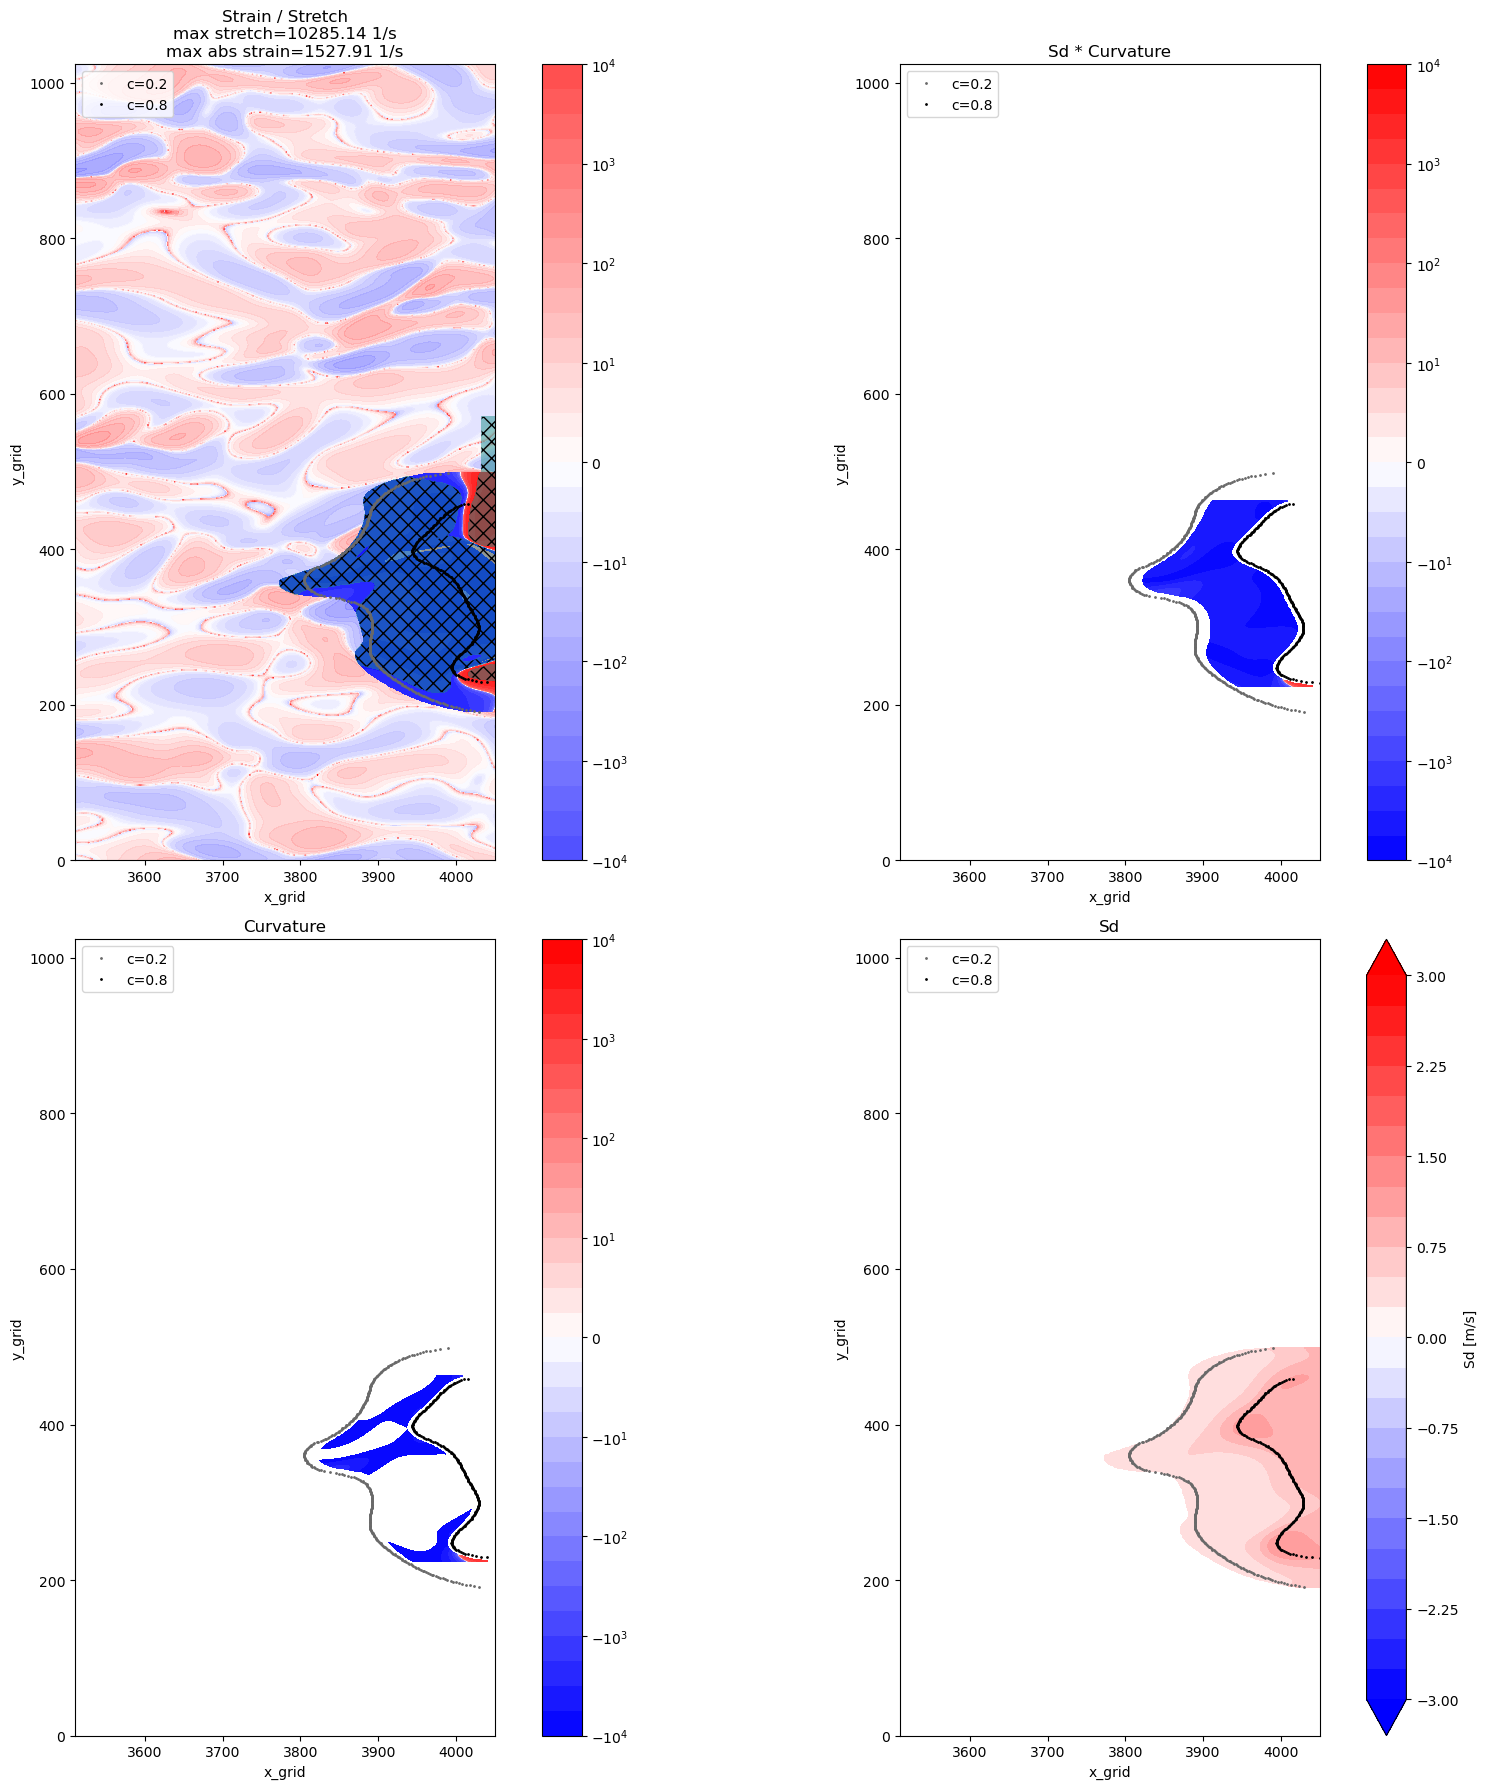

In [2]:
plot_strainrate_slice('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate/amr4_strainrate_p42p5/plt75600_strain_rate.csv',
                      '/home/u0890475/Downloads/amr4_curv_combtest/plt75600_curvature.csv',
                      yh2_u=0.012181,method=2,file_label='log10')



In [9]:
df_test1 = pd.read_csv('/home/u0890475/Downloads/plt75600_curvature.csv')
dff1 = df_test1[df_test1['z_grid']==1]


In [13]:
dff1[(dff1['y_grid']>=250)&(dff1['y_grid']<=350)& (dff1['z_grid']>=3900) & (dff1['z_grid']<=3950) ]

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx


In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
def log_label(x,pos):
        if np.isclose(x,0):
            return "0"
        sign= "-" if x<0 else ""
        exp=int(np.round(abs(x)))
        return rf"${sign}10^{{{abs(int(x))}}}$"



def plot_flame_contour(df_ff01,df_ff05,label1='c=0.1',label2='c=0.5'):
    fig,ax = plt.subplots(figsize=(12,9))
    ax.plot(df_ff01['x_grid'],df_ff01['y_grid'],'.',markersize=2,color='dimgrey',label=label1)
    ax.plot(df_ff05['x_grid'],df_ff05['y_grid'],'.',markersize=2,color='black',label=label2)
    
    return fig,ax

def plot_sr_sum(df_ff01,df_ff05,df,sr_threshold,i,name,file_label=''):
    df2 = df.copy()
    try:
        df2['stretch_rate'] = df2['div_u'] + df2['k']*df2['Sd']
    except:
        print("Unable to get Stretch rate!!!")

    df2_flame = df2[ (df2['c']>=0.15) & (df2['c']<=0.85) & (df2['Sd'] == df2['Sd'] ) ]
    max_str = df2_flame['stretch_rate'].max()
    # plot flame range
    fig,ax=plot_flame_contour(df_ff01,df_ff05,label1='c=0.15',label2='c=0.85')
    pn_divu = np.where(df2['div_u']>0,1,-1)
    log_abs_divu = np.log10(abs(df2['div_u'])+1e-5)
    df2['pn_log_divu'] = pn_divu  * log_abs_divu
    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_divu',
        aggfunc='median',
    )
    pn_str = np.where(df2['stretch_rate']>0,1,-1)
    log_abs_str = np.log10(abs(df2['stretch_rate'])+1e-5)
    df2_flame['np_log_str'] = pn_str*log_abs_str
    str_grid = df2_flame.pivot_table(index='y_grid', columns='x_grid', values='np_log_str', aggfunc='median',)
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    
    X1=str_grid.columns.values
    Y1=str_grid.index.values
    Z1=str_grid.values
    
    max_sr = np.abs(df2[df2['c']<=0.5]['div_u']).max()
    
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
    cf1 = ax.contourf(X1,Y1,Z1,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    cf2= ax.contourf(X1,Y1,np.abs(Z1)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
    cbar =plt.colorbar(cf,ax=ax,label='Strain Rate in power of 10-scale')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabel('y_grid')
    ax.set_title(f'z_grid={i} w/ max stretch rate:{round(max_str,2)} 1/s,\n max abs strain rate :{round(max_sr,2)} 1/s.')
    ax.legend()
    fig.tight_layout()
    plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_(sr)(str)sum_z={i}.png',dpi=600)
    print(f'plot saved for layer i={i}!')
    plt.show()



def plot_stretch(df_ff01,df_ff05,df,sr_threshold,i,name,file_label='',):
    df2 = df.copy()
    fig,ax=plot_flame_contour(df_ff01,df_ff05,label1='c=0.15',label2='c=0.85')
    try:
        df2['stretch_rate']= df2['div_u'] + df2['Sd']*df2['k']
    except:
        print(" Can't find stretch rate")
        return
    pn_divu = np.where(df2['stretch_rate']>0,1,-1)
    log_abs_divu = np.log10(abs(df2['stretch_rate'])+1e-5)
    df2['pn_log_str'] = pn_divu  * log_abs_divu
    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_str',
        aggfunc='median',
    )
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    max_sr = np.abs(df2[df2['c']<=0.5]['stretch_rate']).max()
    levels=np.linspace(-4,4,33)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    
    #cf2=ax.contourf(X,Y,np.abs(Z)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
    cbar =plt.colorbar(cf,ax=ax,label='Stretch Rate')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabel('y_grid')
    ax.set_title(f'z_grid={i} w/ max abs stretch rate :{round(max_sr,2)} 1/s.')
    ax.legend()
    fig.tight_layout()
    #plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_srsum_z={i}.png',dpi=600)
    plt.show()




    



def plot_strainrate_slice(
    d1,
    d2,
    yh2_u,
    method=1,
    file_label='',
    sr_threshold=3300,
):
    from matplotlib.ticker import FuncFormatter
    import matplotlib.pyplot as plt
    
    #plt.figure(figsize=(12,9))
    # d1: strain rate
    # d2: curvature
    df = pd.read_csv(d1,usecols=['dudx','dvdy','dwdz','x_grid','y_grid','z_grid'])
    try:
        df['div_u']= df['dudx'] + df['dvdy'] + df['dwdz']
    except:
        pass
    #print(df['z_grid'].max(), df['z_grid'].min())
    try:
        df = df.drop(columns=["T","ux","uy","uz"])
    except:
        print("Temperature is not included or removed already!!!")
        
    #df_sr = df[ (df['div_u'] >= sr_threshold) | (df['div_u']<= -sr_threshold) ].copy()
    name = d1.split('/')[-1].split('.')[0]
    
    
    
    dfcurv_r = pd.read_csv(d2)
    dfcurv_r = dfcurv_r[(dfcurv_r['x_grid']>=3510) & (dfcurv_r['x_grid']<=4060)]
    dfcurv_r['c'] = 1 - dfcurv_r['Y(H2)']/yh2_u

    ff_idx = dfcurv_r[dfcurv_r['c']>=0.05]['x_grid'].idxmin()
    ff_ygrid = dfcurv_r['y_grid'].iloc[ff_idx]
    ff_xgrid = dfcurv_r['x_grid'].iloc[ff_idx]
    df_sr_verticalcut = df[(df['y_grid'] ==ff_ygrid) & (df['x_grid'] >=(ff_xgrid+50))  ]
    
    
    dfcurv_r= dfcurv_r.set_index(['x_grid','y_grid','z_grid']).copy()

    
    pn_div_u = np.where(df_sr_verticalcut["div_u"]>0,1,-1 )
    log_abs_div_u =np.log10(abs(df_sr_verticalcut['div_u']+1e-5))
    df_sr_verticalcut['pn_log_div_u'] = pn_div_u * log_abs_div_u

    df = df.join(dfcurv_r, on=[ 'x_grid','y_grid','z_grid']) 
    #df = df[df['Sd'].notna()].copy()
    
    #return df
    #df['stretch_rate'] = df['div_u'] + df['Sd']*df['k']
    pvt2 = df_sr_verticalcut.pivot_table(index='z_grid',columns='x_grid',values='pn_log_div_u',aggfunc='median',)
    X2=pvt2.columns.values
    Y2=pvt2.index.values
    Z2=pvt2.values
    
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    #mask = np.abs(Z)>= sr_threshold
    fig, ax = plt.subplots(figsize=(12,9))
    cf_vertical=ax.contourf(
        X2,
        Y2,
        Z2,
        levels=levels,
        cmap='bwr',
        vmin=vmin,
        vmax=vmax,
    )
    
    ax.set_aspect("equal",adjustable="box")
    
    cbar =plt.colorbar(cf_vertical,ax=ax,label='Strain Rate in power of 10-scale')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_xlabel('X_grid')
    ax.set_ylabel('Z_grid')
    ax.set_ylim(0,32)
    ax.set_xlim(3850,3900)
    ax.set_title(f'y_grid={ff_ygrid} Vertical Slice')
    plt.savefig(f'{name}_FF_VerticalSlice.png',dpi=600)
    #plt.show()

    
    
    for i in range(1,8):
        #fig,ax = plt.subplots(figsize=(12,9))
        df_zcut = df[df['z_grid']==i]
        df_z015 = df_zcut[df_zcut['c']>=0.15]
        df_z05 = df_zcut[df_zcut['c']>=0.5]
        df_z085 = df_zcut[df_zcut['c']>=0.85]
        df_zcold = df_zcut[df_zcut['c']<=0.5]
        max_sr = max(abs(df_zcold['div_u']))
        df_fflow = df_z015.loc[df_z015.groupby('y_grid')['x_grid'].idxmin()].copy()
        df_ffhigh = df_z085.loc[df_z085.groupby('y_grid')['x_grid'].idxmin()].copy()

        if method==1:
            print('method1')
    
    
        # method 2
        elif(method==2):
            
            #plot_stretch(df_fflow,df_ffhigh,df_zcut,sr_threshold,i,name,file_label,)
            plot_sr_sum(df_fflow,df_ffhigh,df_zcut,sr_threshold,i,name,file_label)

,dudx,dvdy,dwdz,x_grid,y_grid,z_grid,div_u,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,c
21821258,79.163049,103.981634,-216.312683,3805,358,1,-33.168000,304.126381,58936.867753,101324.948066,0.983152,1201.200281,0.010347,0.041444,-12516.673373,0.447389,232718.279046,102312.448847,0.150538
21821294,78.518222,67.585933,-179.138082,3805,359,1,-33.033926,303.973256,57231.672139,101324.947183,0.984186,1200.352516,0.010340,0.041425,-13043.520566,0.447440,226913.558636,99876.932440,0.151103
21821295,89.804513,81.366953,-238.461397,3805,359,2,-67.289931,307.760070,53500.370782,101324.935756,0.972404,1200.078856,0.010351,0.041853,-11352.852326,-0.136902,215727.941832,-28763.105832,0.150213
21821330,78.190018,31.662404,-142.239335,3805,360,1,-32.386913,303.786564,55239.959212,101324.946962,0.985399,1199.375778,0.010337,0.041406,-13438.338633,0.447589,219851.346322,96920.269057,0.151395
21821331,91.475730,31.713894,-187.762572,3805,360,2,-64.572949,307.452769,51649.998154,101324.936590,0.973981,1199.085331,0.010348,0.041821,-11702.005513,-0.135512,209014.964405,-27630.165316,0.150502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31299918,-582.154617,538.047850,516.594416,4060,494,5,472.487649,311.696375,29469.036693,101324.155662,0.990190,1152.570426,0.010247,0.042473,1081.975999,0.651445,322205.646703,207814.359841,0.158751
31299919,-464.562499,639.685808,405.497272,4060,494,6,580.620581,316.750787,49650.594910,101324.178913,0.975666,1151.511725,0.010133,0.042883,77.818098,0.609304,410294.613903,243867.656081,0.168121
31299920,-327.260119,752.101885,247.101579,4060,494,7,671.943345,322.901946,83455.662313,101324.278256,0.958379,1150.553643,0.010007,0.043390,-680.649263,0.565536,507304.460259,274885.360221,0.178435
31299955,-502.890651,602.204081,376.058435,4060,495,6,475.371865,313.025379,32240.330016,101324.228132,0.985541,1153.101212,0.010305,0.042678,49.170002,0.614475,335116.255438,202915.220555,0.153998


In [1]:
def plot_sr_sum(
    df_ff01,
    df_ff05,
    df,
    sr_threshold,
    i,
    name,
    file_label='',
):

    df2=df.copy()

    try:
        df2['stretch_rate']=(
            df2['div_u']
            +
            df2['k']*df2['Sd']
        )
    except:
        print("Unable to get Stretch rate!!!")

    df2_flame=df2[
        (df2['c']>=0.15)
        &
        (df2['c']<=0.85)
        &
        (df2['Sd'].notna())
    ].copy()

    df2_flame['sdk']=(
        df2_flame['Sd']
        *
        df2_flame['k']
    )

    max_str=df2_flame['stretch_rate'].max()

    fig,axs=plt.subplots(
        2,
        2,
        figsize=(18,18)
    )

    ax=axs[0,0]
    ax_sd=axs[0,1]
    ax_k=axs[1,0]
    ax_sdk=axs[1,1]

    # ============================================================
    # flame contours on all panels
    # ============================================================

    for a in [ax,ax_sd,ax_k,ax_sdk]:

        a.plot(
            df_ff01['x_grid'],
            df_ff01['y_grid'],
            '.',
            markersize=2,
            color='dimgrey'
        )

        a.plot(
            df_ff05['x_grid'],
            df_ff05['y_grid'],
            '.',
            markersize=2,
            color='black'
        )

    # ============================================================
    # original strain/stretch panel
    # ============================================================

    pn_divu=np.where(
        df2['div_u']>0,
        1,
        -1
    )

    log_abs_divu=np.log10(
        np.abs(df2['div_u'])+1e-5
    )

    df2['pn_log_divu']=(
        pn_divu
        *
        log_abs_divu
    )

    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_divu',
        aggfunc='median',
    )

    pn_str=np.where(
        df2['stretch_rate']>0,
        1,
        -1
    )

    log_abs_str=np.log10(
        np.abs(df2['stretch_rate'])+1e-5
    )

    df2['pn_log_str']=(
        pn_str
        *
        log_abs_str
    )

    str_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_str',
        aggfunc='median',
    )

    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values

    X1=str_grid.columns.values
    Y1=str_grid.index.values
    Z1=str_grid.values

    levels=np.linspace(
        -4,
        4,
        33
    )

    cf=ax.contourf(
        X,
        Y,
        Z,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
        alpha=0.7
    )

    cf1=ax.contourf(
        X1,
        Y1,
        Z1,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cf2=ax.contourf(
        X,
        Y,
        np.abs(Z)>=np.log10(sr_threshold),
        levels=[0.5,1],
        hatches=['xx'],
        alpha=0.5,
    )

    cbar=plt.colorbar(
        cf,pos
        ax=ax
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    max_sr=np.abs(
        df2[df2['c']<=0.5]['div_u']
    ).max()

    ax.set_title(
        f'Strain / Stretch\n'
        f'max stretch={round(max_str,2)} 1/s\n'
        f'max abs strain={round(max_sr,2)} 1/s'
    )

    # ============================================================
    # Sd panel (NO LOG)
    # ============================================================

    sd_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='Sd',
        aggfunc='median',
    )

    cf_sd=ax_sd.contourf(
        sd_grid.columns.values,
        sd_grid.index.values,
        sd_grid.values,
        levels=np.linspace(-10,10,41),
        cmap='bwr',
        vmin=-10,
        vmax=10,
        extend='both',
    )

    plt.colorbar(
        cf_sd,
        ax=ax_sd,
        label='Sd [m/s]'
    )

    ax_sd.set_title('Sd')

    # ============================================================
    # Curvature panel
    # ============================================================

    df2_flame['plot_k']=(
        np.sign(df2_flame['k'])
        *
        np.log10(
            np.abs(df2_flame['k'])+1e-5
        )
    )

    k_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='plot_k',
        aggfunc='median',
    )

    cf_k=ax_k.contourf(
        k_grid.columns.values,
        k_grid.index.values,
        k_grid.values,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cbar=plt.colorbar(
        cf_k,
        ax=ax_k,
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    ax_k.set_title('Curvature')

    # ============================================================
    # Sd*k panel
    # ============================================================

    df2_flame['plot_sdk']=(
        np.sign(df2_flame['sdk'])
        *
        np.log10(
            np.abs(df2_flame['sdk'])+1e-5
        )
    )

    sdk_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='plot_sdk',
        aggfunc='median',
    )

    cf_sdk=ax_sdk.contourf(
        sdk_grid.columns.values,
        sdk_grid.index.values,
        sdk_grid.values,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cbar=plt.colorbar(
        cf_sdk,
        ax=ax_sdk,
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    ax_sdk.set_title('Sd * Curvature')

    # ============================================================
    # formatting
    # ============================================================

    for a in [ax,ax_sd,ax_k,ax_sdk]:

        a.set_aspect('equal')

        a.set_xlim(
            3510,
            4050
        )

        a.set_ylim(
            0,
            1024
        )

        a.set_xlabel(
            'x_grid'
        )

        a.set_ylabel(
            'y_grid'
        )

    fig.tight_layout()

    plt.savefig(
        f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_z={i}_4panel.png',
        dpi=600
    )

    print(
        f'plot saved for layer i={i}!'
    )

    plt.show()

In [3]:
plot_strainrate_slice('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate/amr4_strainrate_p42p5/plt75600_strain_rate.csv',
                      '/home/u0890475/Downloads/plt75600_curvature.csv',
                      yh2_u=0.012181,method=2,file_label='log10')

NameError: name 'plot_strainrate_slice' is not defined

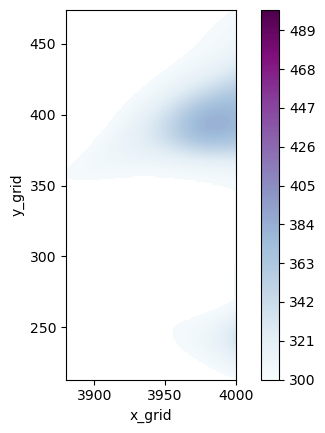

In [34]:
divu_grid=d2f.pivot_table(
    index='y_grid',
    columns='x_grid',
    values='T',
    aggfunc='median',
)

X=divu_grid.columns.values
Y=divu_grid.index.values
Z=divu_grid.values
levels=np.linspace(
    300,
    500,
    201,
)
    
cf=plt.contourf(
    X,
    Y,
    Z,
    levels=levels,
    cmap='BuPu', 
    vmin= 300,
    vmax= 500,
)
plt.xlabel('x_grid')
plt.ylabel('y_grid')
plt.gca().set_aspect('equal')
plt.colorbar(cf)
#plt.savefig('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/plt75800_temp_at_z=0.png',dpi=600)

In [87]:
def get_wall_heatflux(d1,dx=17.0898e-6,x_grid_lim=[3800,4050],y_grid_lim=None,output_dir = './',textlabel=''):
    import matplotlib.pyplot as plt
    d2 = pd.read_csv(d1)
    filename= d1.split('/')[-1].split('.')[0]
    #d2f = d2[(d2['x_grid']>=3800) &(d2['x_grid']<=4000) & (d2['y_grid']>=200)& (d2['y_grid']<=500) & (d2['z_grid']==0) ]
    if (x_grid_lim is not None) or (y_grid_lim is not None):
        try:
            d2 = d2[(d2['x_grid']>=x_grid_lim[0]) & ( d2['x_grid']<=x_grid_lim[1] )]
        except:

            print('Failed to cut in the x regime! Or no cut request on x regime')
        try:
            d2 = d2[(d2['y_grid']>=y_grid_lim[0]) & ( d2['y_grid']<=y_grid_lim[1] )]
        except:
            
            print('Failed to cut in the y regime! Or no cut request on y regime')

    d2f = d2[d2['z_grid']==0]
    print(f'The T max is {d2f['T'].max()}')
    d2f['dTdz'] = (d2f['T'] - 298)/(dy/2)
    d2f['q'] = -(dy**2)*d2f['dTdz']*k_mixture
    divu_grid=d2f.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='T',
        aggfunc='median',
    )
    plt.figure(figsize=(12,9))
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    levels=np.linspace(
        300,
        450,
        201,
    )
        
    cf=plt.contourf(
        X,
        Y,
        Z,
        levels=levels,
        cmap='BuPu', 
        vmin= 300,
        vmax= 450,
    )
    plt.xlabel('x_grid')
    plt.ylabel('y_grid')
    plt.ylim(0,1024)
    plt.gca().set_aspect('equal')
    plt.colorbar(cf)
    #plt.savefig(f'{output_dir}/{filename}_{textlabel}_at_z=0.png', dpi=600)
    #plt.savefig('/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/plt75800_temp_at_z=0.png',dpi=600)
    plt.show()

    return sum(d2f['q'])


Failed to cut in the y regime! Or no cut request on y regime
The T max is 401.4913638207639


/tmp/ipykernel_2027783/3486771715.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2f['dTdz'] = (d2f['T'] - 298)/(dy/2)
/tmp/ipykernel_2027783/3486771715.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2f['q'] = -(dy**2)*d2f['dTdz']*k_mixture


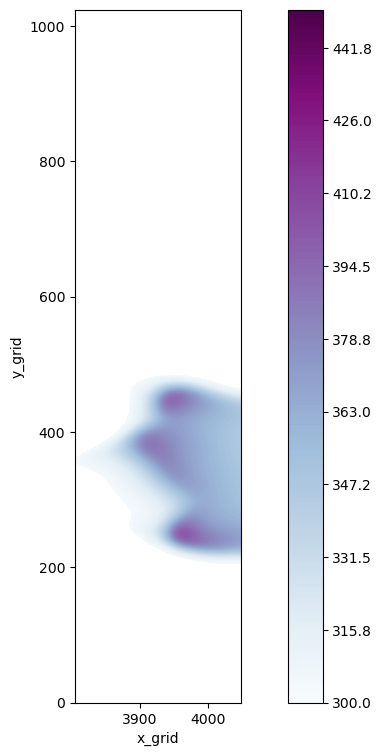

-3.2256618868748994

In [89]:
d1 = '/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75400_curvature.csv'
get_wall_heatflux(d1)

In [413]:
def plot_stretch(
    d1,
    d2,
    yh2_u,
    method=1,
    file_label='',
    sr_threshold=2000,
    sl=0.25,
):
    # this section is used to plot stretch rate 
    from matplotlib.ticker import FuncFormatter
    import matplotlib.pyplot as plt
    
    #plt.figure(figsize=(12,9))
    # d1: strain rate
    # d2: curvature
    df = pd.read_csv(d1,usecols=['dudx','dvdy','dwdz','x_grid','y_grid','z_grid'])
    try:
        df['div_u']= df['dudx'] + df['dvdy'] + df['dwdz']
    except:
        pass
    #print(df['z_grid'].max(), df['z_grid'].min())
    try:
        df = df.drop(columns=["T","ux","uy","uz"])
    except:
        print("Temperature is not included or removed already!!!")
        
    #df_sr = df[ (df['div_u'] >= sr_threshold) | (df['div_u']<= -sr_threshold) ].copy()
    name = d1.split('/')[-1].split('.')[0]
    
    
    
    dfcurv_r = pd.read_csv(d2)
    dfcurv_r = dfcurv_r[(dfcurv_r['x_grid']>=3510) & (dfcurv_r['x_grid']<=4060)]
    dfcurv_r['c'] = 1 - dfcurv_r['Y(H2)']/yh2_u

    df_z01 = dfcurv_r[dfcurv_r['c']>=0.05]
    df_z05 = dfcurv_r[df_zcut['c']>=0.5]
    df_zcold = df_zcut[df_zcut['c']<=0.5]
    max_sr = max(abs(df_zcold['div_u']))
    df_ff01 = df_z01.loc[df_z01.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_ff05 = df_z05.loc[df_z05.groupby('y_grid')['x_grid'].idxmin()].copy()

    # for this section, trying to plot the stretch rate 
    # and plot the flame location
    
    #df_stretch = dfcurv_r[(dfcurv_r['c']>=0.495)& (dfcurv_r['c']<=0.505)]
    df= df.set_index(['x_grid','y_grid','z_grid']).copy()

    df_stretch = df_stretch.join(df, on=['x_grid','y_grid','z_grid']) 
    
    df_stretch['stretch_rate']= df_stretch['div_u'] +sl*df_stretch['k']
    




In [411]:
d1r='/home/u0890475/Documents/SW_analysis_result/amr4/strainrate/amr4_strainrate_p42p5/plt75600_strain_rate.csv'
d2r='/home/u0890475/Documents/SW_analysis_result/amr4/curvature/plt75600_curvature.csv'


3510